In [136]:
import numpy as np
import pandas as pd
from collections import Counter
import warnings, os, gc, re
import matplotlib.pyplot as plt
import swifter
import psutil
import math

# from plotnine import ggplot, aes, geom_line
from plotnine import *
# import pygal as pg
%matplotlib inline

import missingno as msno

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.4f}'.format

In [2]:
path, dirs, files = next(os.walk("chunks/"))
directory = 'chunks/'
file_count = len(files)
year_start = 2013
year_end = 2020

In [ ]:
# # codes in ILLNESS*_CODE that are not ICD-10 codes
# not_icd = ['MCP01', 'NSD01', 'P0000', 'P0001', 'ANC01', 'ANC02']

# #icd-10 philhealth list - 2017
# df_icd10 = pd.read_excel(os.path.join(directory, 'ICD10 philhealth.xlsx'))
# df_icd10 = df_icd10.set_axis(['ILLNESS1_CODE','DESCRIPTION','GROUP','CASE_RATE','PROFESSIONAL_FEE', \
#                               'HEALTH_CARE_INST_FEE'], axis=1, inplace=False)

# #procedures philhealth list - 2015
# df_procs = pd.read_excel(os.path.join(directory, 'Procedures philhealth.xlsx'))
# df_procs = df_procs.set_axis(['ILLNESS1_CODE','DESCRIPTION','CASE_RATE','PROFESSIONAL_FEE', \
#                               'HEALTH_CARE_INST_FEE'], axis=1, inplace=False)

In [3]:
# count number of rows
from itertools import (takewhile,repeat)
def rawincount(filename):
    f = open(filename, 'rb')
    bufgen = takewhile(lambda x: x, (f.raw.read(1024*1024) for _ in repeat(None)))
    return sum( buf.count(b'\n') for buf in bufgen )

# compute for memory usage
def usage():
    process = psutil.Process(os.getpid())
    return process.memory_info()[0] / float(2 ** 20)

In [4]:
# counts per single categorical field
def group_categs(dframe, col_name_grp, ren_cols, total_year):
    df = dframe.groupby([col_name_grp]).size().sort_values(ascending=False).to_frame().reset_index() \
                .set_axis([ren_cols, 'Freq.'], axis=1, inplace=False)
    df['Percent'] = ((df['Freq.'].values/total_year)*100)
    df['Freq.'] = df.swifter.progress_bar(False).apply(lambda x: '{:,}'.format(x['Freq.']),axis=1)
    df['Percent'] = df.swifter.progress_bar(False).apply(lambda x: '{:,.2f}'.format(x['Percent']),axis=1)
    return df

# reference: https://bip.weizmann.ac.il/course/python/PyMOTW/PyMOTW/docs/gc/index.html
import pprint
def garbage_collector():
    for i in range(4):
        print('Collecting %d ...' % i)
        n = gc.collect()
        print('Unreachable objects:', n)
        print('Remaining Garbage:',) 
        pprint.pprint(gc.garbage)
        print

# 2013

### Read Input File

In [7]:
# year_upd = 2013
# df1 = pd.read_csv(os.path.join(directory, str(year_upd) + '_new_1.csv'), low_memory=False, index_col=0)
df1 = pd.read_csv('58120.csv', low_memory=False, index_col=0)

# for lighter pandas df and faster execution
df1['PRO_NAME'] = df1['PRO_NAME'].astype('category')
df1['INSTITUTION_NAME'] = df1['INSTITUTION_NAME'].astype('category')
df1['OWNERSHIP'] = df1['OWNERSHIP'].astype('category')
df1['INSTITUTION_CLASS'] = df1['INSTITUTION_CLASS'].astype('category')
df1['INSTITUTION_PROVINCE'] = df1['INSTITUTION_PROVINCE'].astype('category')
df1['INSTITUTION_MUNICIPALITY'] = df1['INSTITUTION_MUNICIPALITY'].astype('category')
df1['MEM_CATEGORY'] = df1['MEM_CATEGORY'].astype('category')
# df1['MEM_SUB_CATEGORY'] = df1['MEM_SUB_CATEGORY'].astype('category')

# writer = pd.ExcelWriter(os.path.join(directory, str(year_upd) + '_totals_ACTUAL_AMT.xlsx'), engine='xlsxwriter')

df1.head()

,PRO_NAME,INSTITUTION_NAME,OWNERSHIP,INSTITUTION_CLASS,INSTITUTION_PROVINCE,INSTITUTION_MUNICIPALITY,MEM_CATEGORY,PATIENT_AGE,PATIENT_SEX,PROVINCE,...,ILLNESS_1_ACR_AMT,ILLNESS_1_EST_AMT,ILLNESS_2_ACR_AMT,ILLNESS_2_EST_AMT,ACTUAL_AMT,PAID AMOUNT,CHECK_DT,CLAIM_STATUS,CLAIM_SUB_STATUS,RECEIVED/REFILED DATE
YEAR,,,,,,,,,,,,,,,,,,,,,
2013,PRO IVA,STA. ROSA COMMUNITY HOSPITAL,GOVERNMENT OWNED,LEVEL 1 HOSPITAL,LAGUNA,STA. ROSA,SPONSORED,28.0000,F,LAGUNA,...,NaN,NaN,NaN,NaN,9786.0000,4852.0000,2013-07-22,PAID,PAID,2013-06-21
2013,PRO IVA,DOÑA MARTA MEMORIAL DISTRICT HOSPITAL,LGU,LEVEL 1 HOSPITAL,QUEZON,ATIMONAN,FORMAL ECONOMY,23.0000,F,QUEZON,...,NaN,NaN,NaN,NaN,5426.0000,5426.0000,2013-02-14,PAID,PAID,2013-01-21
2013,PRO V,AGO GENERAL HOSPITAL,CORPORATE,LEVEL 1 HOSPITAL,ALBAY,LEGAZPI CITY,LIFETIME MEMBER,73.0000,F,ALBAY,...,NaN,NaN,NaN,NaN,29084.0000,8104.0000,2013-05-21,PAID,PAID,2013-02-22
2013,PRO IIIA,GILBERTO O. TEODORO MEMORIAL HOSPITAL,LGU,LEVEL 1 HOSPITAL,TARLAC,CAMILING,INFORMAL ECONOMY,43.0000,F,TARLAC,...,NaN,NaN,NaN,NaN,5880.0000,3730.0000,2013-07-24,PAID,PAID,2013-05-16
2013,PRO XI,CARMEN MEDICAL CLINIC AND HOSPITAL,SINGLE PROPRIETORSHIP,INFIRMARY/DISPENSARY,DAVAO DEL NORTE,CARMEN,SPONSORED,39.0000,F,DAVAO DEL NORTE,...,NaN,NaN,NaN,NaN,9170.0000,5015.0000,2013-05-15,PAID,PAID,2013-05-06


In [155]:
# stats on number of rows with certain ACTUAL_AMT values
total_year = len(df1.index)
total_na = len(df1[df1['ACTUAL_AMT'].isna()])
total_more_10M = len(df1[df1['ACTUAL_AMT'] >= 10000000])
total_less_1M = len(df1[(df1['ACTUAL_AMT'] <= 1000000)])
total_less_500k = len(df1[(df1['ACTUAL_AMT'] <= 500000)])
total_less_300k = len(df1[(df1['ACTUAL_AMT'] <= 300000)])
total_less_200k = len(df1[(df1['ACTUAL_AMT'] <= 200000)])
total_less_100k = len(df1[(df1['ACTUAL_AMT'] <= 100000)])
total_less_50k = len(df1[(df1['ACTUAL_AMT'] <= 50000)])
total_500_or_less = len(df1[(df1['ACTUAL_AMT'] <= 500)])
total_less_0to1 = len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])
total_neg = len(df1[(df1['ACTUAL_AMT'] < 0)])
df_stats = pd.DataFrame([['No. of Rows with No ACTUAL_AMT keyed in', total_na, 100*total_na/total_year],
                        ['No. of Rows with ACTUAL_AMT > 10M', total_more_10M, 100*total_more_10M/total_year],
                        ['No. of Rows with ACTUAL_AMT <= 1M', total_less_1M, 100*total_less_1M/total_year],
                        ['No. of Rows with ACTUAL_AMT <= 500k', total_less_500k, 100*total_less_500k/total_year],
                        ['No. of Rows with ACTUAL_AMT <= 300k', total_less_300k, 100*total_less_300k/total_year],
                        ['No. of Rows with ACTUAL_AMT <= 200k', total_less_200k, 100*total_less_200k/total_year],
                        ['No. of Rows with ACTUAL_AMT <= 100k', total_less_100k, 100*total_less_100k/total_year],
                        ['No. of Rows with ACTUAL_AMT <= 50k', total_less_50k, 100*total_less_50k/total_year],
                        ['No. of Rows with ACTUAL_AMT <= 500', total_500_or_less, 100*total_500_or_less/total_year], 
                        ['No. of Rows with ACTUAL_AMT bet 0.0-1.0', total_less_0to1, 100*total_less_0to1/total_year],
                        ['No. of Rows with Negative ACTUAL_AMT', total_neg, 100*total_neg/total_year],
                        ['Total No. of Rows', total_year, 100*total_year/total_year]],
                       columns=['Rows', 'Freq.', 'Percent'])
# df_stats.to_excel(writer, sheet_name='ACTUAL_AMT stats')
df_stats

,Rows,Freq.,Percent
0,No. of Rows with No ACTUAL_AMT keyed in,0,0.0000
1,No. of Rows with ACTUAL_AMT > 10M,10,0.0026
2,No. of Rows with ACTUAL_AMT <= 1M,382822,99.9825
3,No. of Rows with ACTUAL_AMT <= 500k,382797,99.9760
4,No. of Rows with ACTUAL_AMT <= 300k,382745,99.9624
5,No. of Rows with ACTUAL_AMT <= 200k,382621,99.9300
6,No. of Rows with ACTUAL_AMT <= 100k,381295,99.5837
7,No. of Rows with ACTUAL_AMT <= 50k,364909,95.3041
8,No. of Rows with ACTUAL_AMT <= 500,123277,32.1965
9,No. of Rows with ACTUAL_AMT bet 0.0-1.0,114310,29.8546


In [ ]:
# this lists down the values of the top 20 highest ACTUAL_AMT values
# will have to filter these out because it is causing errors in plotting histograms,
# since the number of bins is determined by the max value / bin width, and the max value
# causes memory overflows
df1[df1['ACTUAL_AMT'] >= 10000000].sort_values(['ACTUAL_AMT'], ascending=False)['ACTUAL_AMT'] \
            .to_frame().head(20) \
            .to_excel(writer, sheet_name='Top 20 ACTUAL_AMT Values')

In [49]:
df2 = df1[(df1['ACTUAL_AMT'] <= 100000) & (~df1['ACTUAL_AMT'].isna()) & (df1['ACTUAL_AMT'] >= 1.0)]['ACTUAL_AMT'].to_frame()
df2.head()

,ACTUAL_AMT
YEAR,
2013,9786.0000
2013,5426.0000
2013,29084.0000
2013,5880.0000
2013,9170.0000


In [ ]:
# just to check which regions key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Region')

In [ ]:
# just to check which provinces key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Prov')

In [ ]:
# just to check which regions key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Region')

In [ ]:
# just to check which provinces key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Prov')

In [ ]:
# write spreadsheets above
writer.save()

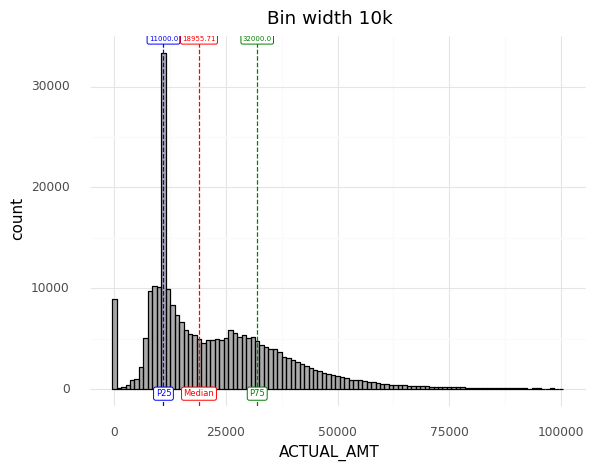

<ggplot: (158643232582)>

In [154]:
# reference: https://plotnine.readthedocs.io/en/stable/generated/plotnine.geoms.geom_histogram.html
# Plot ALL values, with binwidth = 100000 (ACTUAL_AMT = 100k increments per bin)
med_value = df2['ACTUAL_AMT'].median()
q_25 = df2['ACTUAL_AMT'].quantile(0.25)
q_75 = df2['ACTUAL_AMT'].quantile(0.75)
max_val = len(df2['ACTUAL_AMT'])

p = ggplot(aes(x='ACTUAL_AMT'), data=df2)
p + geom_histogram(binwidth=1000, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle('Bin width 10k') \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()
#     + geom_text(aes(x=med_value, 
#                     label=med_value, 
#                     y=0), 
#                 colour="blue") 
#     + scale_x_continuous(breaks=(1,100000)) \
#     + geom_density(column=100) \
#     + geom_label(aes(6, 1.2), label = "Target Length") \
#     + geom_shadowtext(
#           label = paste0("value = ", round(mean(df$numbers) * 2.5, 0), "€"),
#           x = mean(df$numbers) * 2.5, y = 4, size = 4, colour = "#FFBA18")
#     + coord_cartesian(ylim=list(np.arange(-10, 60000, 1000))) \

In [ ]:
# since most of the amounts are in the >200k range, we then re-plot the histogram, 
# this time including amounts within those range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 200000)])
p + geom_histogram(binwidth=5000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 200k, bin width 5k') \
    + theme_minimal()

In [ ]:
# re-plotting the histogram, 
# this time including amounts from 0-100k range, bin width set to 1k value
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 100000)])
p + geom_histogram(binwidth=1000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 100k, bin width 1k') \
    + theme_minimal()

In [ ]:
# plotting amounts within 0-1 range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] < 1) & (df2['ACTUAL_AMT'] >= 0)])
p + geom_histogram(binwidth=0.01, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT 0.0-1.0, bin width 0.01') \
    + theme_minimal()

In [ ]:
# mapping missing values first (NaN values only)
# ref https://coderzcolumn.com/tutorials/data-science/missingno-visualize-missing-data-in-python
msno.matrix(df1, figsize=(15,7), fontsize=12)

In [ ]:
# mapping missing values first (NaN values only)
msno.heatmap(df1, figsize=(15,7), fontsize=12)

In [ ]:
# mapping missing values, setting 0 values as NaN as well
df3 = df1
df3.loc[(df3['ACTUAL_AMT'] < 1) & (df3['ACTUAL_AMT'] >= 0),['ACTUAL_AMT']] = np.nan
msno.matrix(df3, figsize=(15,7), fontsize=12)

In [ ]:
# mapping missing values, setting 0 values as NaN as well
msno.heatmap(df3, figsize=(15,7), fontsize=12)

In [ ]:
# clear dataframes before next runs
del[df1, df2, df3, df_stats]
garbage_collector()

### Read Input File

In [ ]:
year_upd = 2020
df1 = pd.read_csv(os.path.join(directory, str(year_upd) + '_new_1.csv'), low_memory=False, index_col=0)

# for lighter pandas df and faster execution
df1['PRO_NAME'] = df1['PRO_NAME'].astype('category')
df1['INSTITUTION_NAME'] = df1['INSTITUTION_NAME'].astype('category')
df1['OWNERSHIP'] = df1['OWNERSHIP'].astype('category')
df1['INSTITUTION_CLASS'] = df1['INSTITUTION_CLASS'].astype('category')
df1['INSTITUTION_PROVINCE'] = df1['INSTITUTION_PROVINCE'].astype('category')
df1['INSTITUTION_MUNICIPALITY'] = df1['INSTITUTION_MUNICIPALITY'].astype('category')
df1['MEM_CATEGORY'] = df1['MEM_CATEGORY'].astype('category')
df1['MEM_SUB_CATEGORY'] = df1['MEM_SUB_CATEGORY'].astype('category')

writer = pd.ExcelWriter(os.path.join(directory, str(year_upd) + '_totals_ACTUAL_AMT.xlsx'), engine='xlsxwriter')

df1.head()

In [ ]:
# stats on number of rows with certain ACTUAL_AMT values
total_year = len(df1.index)
total_na = len(df1[df1['ACTUAL_AMT'].isna()])
total_more_10M = len(df1[df1['ACTUAL_AMT'] >= 10000000])
total_less_1M = len(df1[(df1['ACTUAL_AMT'] < 1000000)])
total_less_500k = len(df1[(df1['ACTUAL_AMT'] < 500000)])
total_less_300k = len(df1[(df1['ACTUAL_AMT'] < 300000)])
total_less_200k = len(df1[(df1['ACTUAL_AMT'] < 200000)])
total_less_100k = len(df1[(df1['ACTUAL_AMT'] < 100000)])
total_less_50k = len(df1[(df1['ACTUAL_AMT'] < 50000)])
total_500_or_less = len(df1[(df1['ACTUAL_AMT'] <= 500)])
total_less_0to1 = len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])
total_neg = len(df1[(df1['ACTUAL_AMT'] < 0)])
df_stats = pd.DataFrame([['No. of Rows with No ACTUAL_AMT keyed in', total_na, 100*total_na/total_year],
                        ['No. of Rows with ACTUAL_AMT > 10M', total_more_10M, 100*total_more_10M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 1M', total_less_1M, 100*total_less_1M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 500k', total_less_500k, 100*total_less_500k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 300k', total_less_300k, 100*total_less_300k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 200k', total_less_200k, 100*total_less_200k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 100k', total_less_100k, 100*total_less_100k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 50k', total_less_50k, 100*total_less_50k/total_year],
                        ['No. of Rows with ACTUAL_AMT <= 500', total_500_or_less, 100*total_500_or_less/total_year], 
                        ['No. of Rows with ACTUAL_AMT bet 0.0-1.0', total_less_0to1, 100*total_less_0to1/total_year],
                        ['No. of Rows with Negative ACTUAL_AMT', total_neg, 100*total_neg/total_year],
                        ['Total No. of Rows', total_year, 100*total_year/total_year]],
                       columns=['Rows', 'Freq.', 'Percent'])
df_stats.to_excel(writer, sheet_name='ACTUAL_AMT stats')
df_stats

In [ ]:
# this lists down the values of the top 20 highest ACTUAL_AMT values
# will have to filter these out because it is causing errors in plotting histograms,
# since the number of bins is determined by the max value / bin width, and the max value
# causes memory overflows
df1[df1['ACTUAL_AMT'] >= 10000000].sort_values(['ACTUAL_AMT'], ascending=False)['ACTUAL_AMT'] \
            .to_frame().head(20) \
            .to_excel(writer, sheet_name='Top 20 ACTUAL_AMT Values')

In [ ]:
df2 = df1[(df1['ACTUAL_AMT'] < 10000000) & (~df1['ACTUAL_AMT'].isna())]['ACTUAL_AMT'].to_frame()
df2.head()

In [ ]:
# just to check which regions key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Region')

In [ ]:
# just to check which provinces key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Prov')

In [ ]:
# just to check which regions key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Region')

In [ ]:
# just to check which provinces key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Prov')

In [ ]:
# write spreadsheets above
writer.save()

In [ ]:
# reference: https://plotnine.readthedocs.io/en/stable/generated/plotnine.geoms.geom_histogram.html
# Plot ALL values, with binwidth = 100000 (ACTUAL_AMT = 100k increments per bin)
p = ggplot(aes(x='ACTUAL_AMT'), data=df2)
p + geom_histogram(binwidth=100000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT < 10M, bin width 100k') \
    + theme_minimal()

In [ ]:
# since most of the amounts are in the >200k range, we then re-plot the histogram, 
# this time including amounts within those range

# due to errors in binning (extreme negative value causing run issues),
# opted to just remove it instead
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 200000) & (df2['ACTUAL_AMT'] > 0)])
p + geom_histogram(binwidth=5000, 
#                    fill='blue',     # fill color
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 200k, bin width 5k') \
    + theme_minimal()

In [ ]:
# re-plotting the histogram, 
# this time including amounts from 0-100k range, bin width set to 1k value

# due to errors in binning (extreme negative value causing run issues),
# opted to just remove it instead
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 100000) & (df2['ACTUAL_AMT'] > 0)])
p + geom_histogram(binwidth=1000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 100k, bin width 1k') \
    + theme_minimal()

In [ ]:
# plotting amounts within 0-1 range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] < 1) & (df2['ACTUAL_AMT'] >= 0)])
p + geom_histogram(binwidth=0.01, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT 0.0-1.0, bin width 0.01') \
    + theme_minimal()

In [ ]:
# mapping missing values first (NaN values only)
# ref https://coderzcolumn.com/tutorials/data-science/missingno-visualize-missing-data-in-python
msno.matrix(df1, figsize=(15,7), fontsize=12)

In [ ]:
# mapping missing values first (NaN values only)
msno.heatmap(df1, figsize=(15,7), fontsize=12)

In [ ]:
# mapping missing values, setting 0 values as NaN as well
df3 = df1
df3.loc[(df3['ACTUAL_AMT'] < 1) & (df3['ACTUAL_AMT'] >= 0),['ACTUAL_AMT']] = np.nan
msno.matrix(df3, figsize=(15,7), fontsize=12)

In [ ]:
# mapping missing values, setting 0 values as NaN as well
msno.heatmap(df3, figsize=(15,7), fontsize=12)

In [ ]:
# clear dataframes before next runs
del[df1, df2, df3, df_stats]
garbage_collector()